# 02. Density-Based Learning: DBSCAN and HDBSCAN
**Algorithms Covered:**
1. **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)
2. **HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise)

**Core Focus:**
- Discovering clusters of arbitrary shapes and variable densities
- Automatic anomaly and noise identification
- Systematic hyperparameter selection ($k$-distance graph for $\epsilon$ and `min_samples`)
- Comparative benchmark against centroid-based clustering (K-Means)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, HDBSCAN, KMeans
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Aesthetics setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("Density-based libraries loaded successfully!")


Density-based libraries loaded successfully!


## 1. Generating Complex Non-Spherical Benchmark Data
Real-world spatial, geographic, and sensor data often exhibits arbitrary shapes, varying local densities, and background noise where centroid-based algorithms (like K-Means) fail completely.
Here we construct a composite benchmark dataset featuring:
- Two interleaving half moons
- A dense circular core
- A sparser Gaussian blob
- Random uniform background noise (outliers)


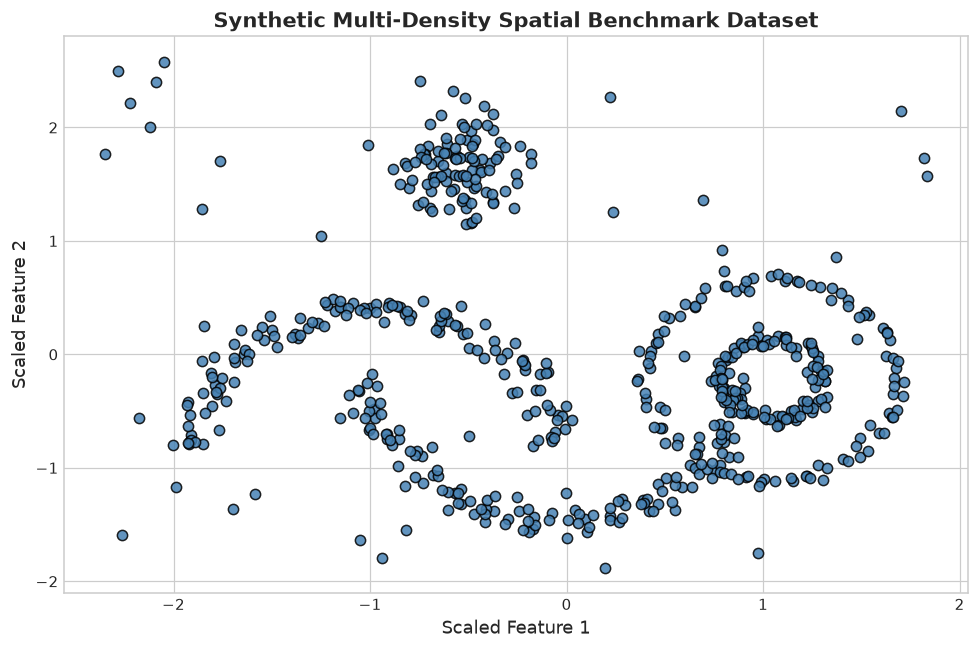

In [2]:
# Generating non-convex manifold dataset
n_samples = 600
X_moons, y_moons = make_moons(n_samples=250, noise=0.06, random_state=42)
X_circle, y_circle = make_circles(n_samples=200, noise=0.04, factor=0.4, random_state=42)
X_circle = X_circle * 0.7 + np.array([2.2, 0.5])

X_blob, y_blob = make_blobs(n_samples=100, centers=[[0.5, 2.0]], cluster_std=0.2, random_state=42)
X_noise = np.random.uniform(low=[-1.5, -1.0], high=[3.2, 2.8], size=(50, 2))

X_raw = np.vstack([X_moons, X_circle, X_blob, X_noise])
# True labels for benchmarking (noise marked as -1)
y_true = np.concatenate([y_moons, y_circle + 2, y_blob + 4, -np.ones(50, dtype=int)])

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c='steelblue', edgecolors='k', s=45, alpha=0.85)
plt.title("Synthetic Multi-Density Spatial Benchmark Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Scaled Feature 1", fontsize=12)
plt.ylabel("Scaled Feature 2", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Why Centroid-Based Clustering (K-Means) Fails on Non-Convex Geometries
K-Means assumes clusters are spherical and isotropic, minimizing Euclidean variance around centroids.
Let's see what happens when K-Means is applied to this non-convex dataset.


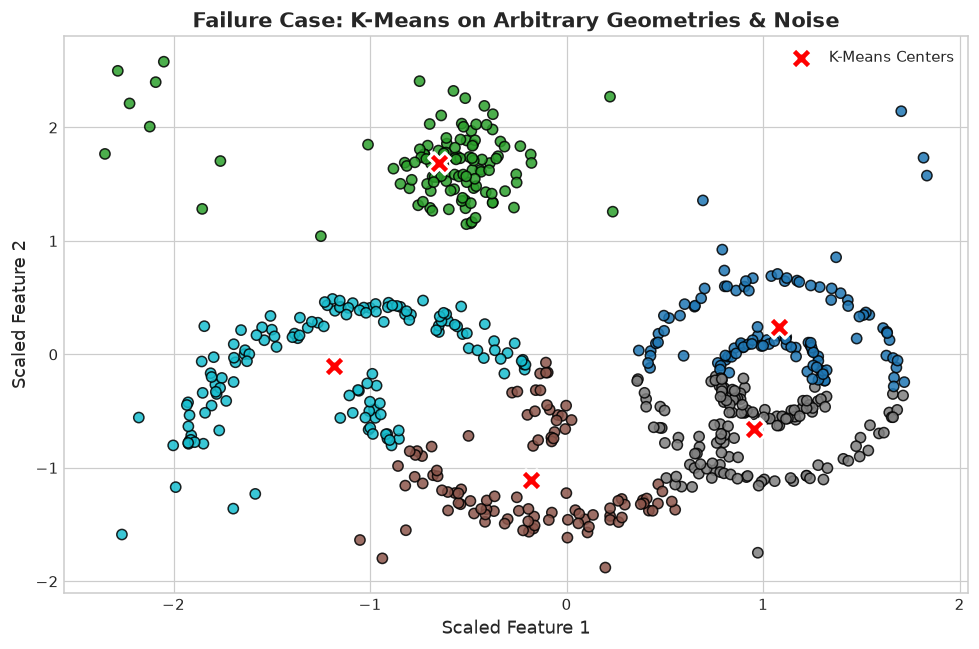

K-Means Adjusted Rand Index (ARI vs ground truth): 0.4426


In [3]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels = km.fit_predict(X)

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=km_labels, cmap='tab10', edgecolors='k', s=45, alpha=0.85)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='red', marker='X', s=200, edgecolors='white', linewidths=2, label='K-Means Centers')
plt.title("Failure Case: K-Means on Arbitrary Geometries & Noise", fontsize=14, fontweight='bold')
plt.xlabel("Scaled Feature 1", fontsize=12)
plt.ylabel("Scaled Feature 2", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"K-Means Adjusted Rand Index (ARI vs ground truth): {adjusted_rand_score(y_true, km_labels):.4f}")


## 3. Algorithm 1: DBSCAN
### Mathematical Concepts
DBSCAN defines clusters as continuous regions of high density separated by regions of low density.
For a dataset $D$:
1. **$\epsilon$-Neighborhood**:
   $$N_\epsilon(p) = \{q \in D \mid \text{dist}(p, q) \le \epsilon\}$$
2. **Core Point**: A point $p$ is a core point if $|N_\epsilon(p)| \ge \text{MinPts}$.
3. **Directly Density-Reachable**: Point $q$ is directly density-reachable from $p$ if $q \in N_\epsilon(p)$ and $p$ is a core point.
4. **Density-Reachable & Density-Connected**: Points connected through chains of core points form a cluster.
5. **Noise / Outliers**: Any point not reachable from any core point is assigned label $-1$.

### Hyperparameter Selection via the $k$-Distance Graph
A standard heuristic for choosing $\epsilon$ is plotting the distance to the $k$-th nearest neighbor sorted in ascending order (where $k = \text{MinPts}$). The "knee" or "elbow" of maximum curvature indicates the threshold where point density sharply drops into noise.


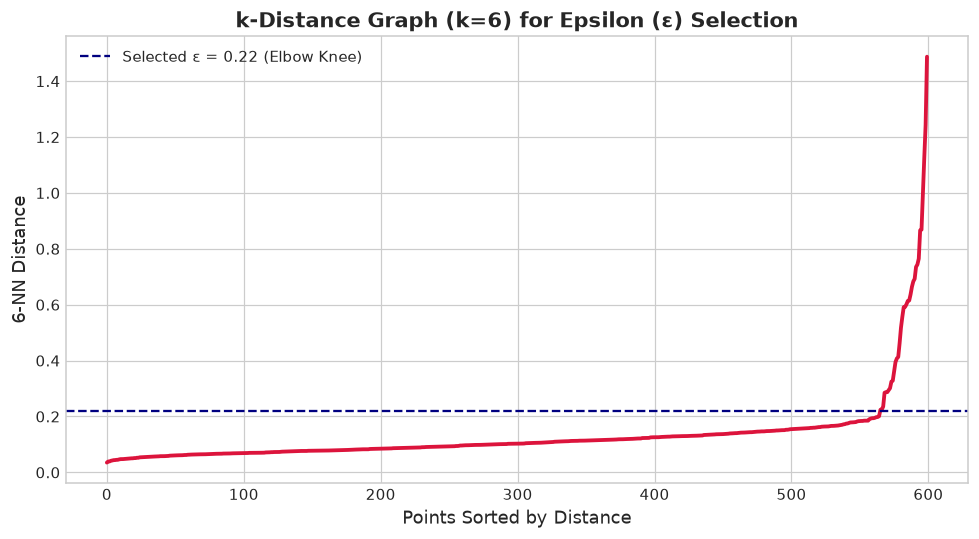

In [4]:
min_samples = 6 # MinPts rule: >= 2 * dimensions
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, indices = nbrs.kneighbors(X)

# Distance to the k-th nearest neighbor (sorted)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='crimson', linewidth=2.5)
plt.title(f"k-Distance Graph (k={min_samples}) for Epsilon (ε) Selection", fontsize=14, fontweight='bold')
plt.xlabel("Points Sorted by Distance", fontsize=12)
plt.ylabel(f"{min_samples}-NN Distance", fontsize=12)
plt.axhline(y=0.22, color='navy', linestyle='--', label='Selected ε = 0.22 (Elbow Knee)')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Fitting DBSCAN
eps_selected = 0.22
dbscan = DBSCAN(eps=eps_selected, min_samples=min_samples)
db_labels = dbscan.fit_predict(X)

# Distinguish core samples, non-core (border), and noise
core_samples_mask = np.zeros_like(db_labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = np.sum(db_labels == -1)

print(f"DBSCAN Results:")
print(f" - Estimated number of clusters: {n_clusters_db}")
print(f" - Number of noise points: {n_noise_db} ({n_noise_db / len(X) * 100:.1f}%)")
print(f" - Adjusted Rand Index (ARI): {adjusted_rand_score(y_true, db_labels):.4f}")


DBSCAN Results:
 - Estimated number of clusters: 3
 - Number of noise points: 28 (4.7%)
 - Adjusted Rand Index (ARI): 0.4637


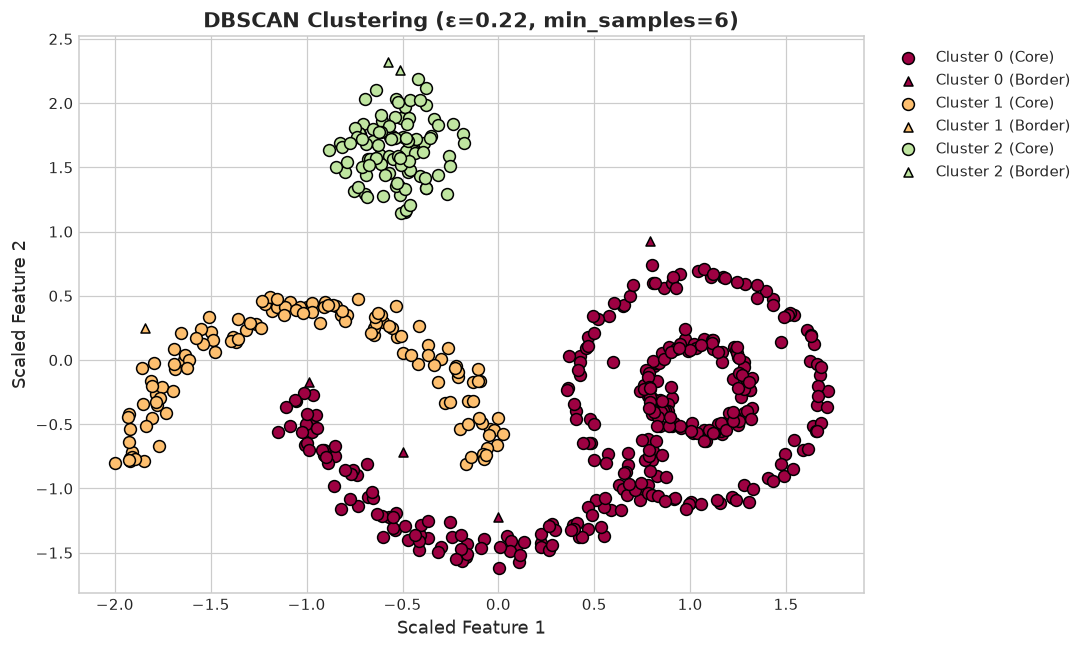

In [6]:
# Visualizing DBSCAN Clusters with Core vs Border vs Noise points
plt.figure(figsize=(10, 6))

unique_labels = set(db_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise
        col = [0, 0, 0, 1]

    class_member_mask = (db_labels == k)

    # Plot core points
    xy_core = X[class_member_mask & core_samples_mask]
    if len(xy_core) > 0:
        plt.scatter(xy_core[:, 0], xy_core[:, 1], color=tuple(col), edgecolors='k', s=60, label=f'Cluster {k} (Core)' if k != -1 else 'Noise')

    # Plot border points
    xy_border = X[class_member_mask & ~core_samples_mask]
    if len(xy_border) > 0 and k != -1:
        plt.scatter(xy_border[:, 0], xy_border[:, 1], color=tuple(col), edgecolors='k', marker='^', s=35, label=f'Cluster {k} (Border)')

plt.title(f"DBSCAN Clustering (ε={eps_selected}, min_samples={min_samples})", fontsize=14, fontweight='bold')
plt.xlabel("Scaled Feature 1", fontsize=12)
plt.ylabel("Scaled Feature 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 4. Algorithm 2: HDBSCAN
### Mathematical Concepts
While DBSCAN uses a single fixed radius $\epsilon$ across the entire space (struggling when clusters possess varying densities), **HDBSCAN** converts DBSCAN into a hierarchical clustering algorithm and extracts the most persistent flat clusters:
1. **Core Distance**: $d_{\text{core}}(p)$ is the distance from $p$ to its $k$-th nearest neighbor.
2. **Mutual Reachability Distance**:
   $$d_{\text{mreach}}(a, b) = \max\{d_{\text{core}}(a), d_{\text{core}}(b), d(a, b)\}$$
3. **Minimum Spanning Tree & Condensed Tree**: A tree is built using mutual reachability as weights, then condensed by tracking cluster births ($\lambda_{\text{birth}} = 1/\epsilon$) and deaths ($\lambda_{\text{death}}$).
4. **Cluster Stability**:
   $$S(C_i) = \sum_{p \in C_i} (\lambda_p - \lambda_{\text{birth}}(C_i))$$
   Clusters with highest accumulated persistence stability are retained.


In [7]:
# Fitting HDBSCAN
hdb = HDBSCAN(min_cluster_size=15, min_samples=6, store_centers='centroid')
hdb_labels = hdb.fit_predict(X)

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise_hdb = np.sum(hdb_labels == -1)

print(f"HDBSCAN Results:")
print(f" - Estimated number of clusters: {n_clusters_hdb}")
print(f" - Number of noise points: {n_noise_hdb} ({n_noise_hdb / len(X) * 100:.1f}%)")
print(f" - Adjusted Rand Index (ARI): {adjusted_rand_score(y_true, hdb_labels):.4f}")


HDBSCAN Results:
 - Estimated number of clusters: 3
 - Number of noise points: 22 (3.7%)
 - Adjusted Rand Index (ARI): 0.4578


d:\ML\Assignment\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


<>:20: SyntaxWarning: invalid escape sequence '\i'
<>:20: SyntaxWarning: invalid escape sequence '\i'
C:\Users\atiku\AppData\Local\Temp\ipykernel_26244\3383436983.py:20: SyntaxWarning: invalid escape sequence '\i'
  cbar.set_label("Membership Probability $P(x_i \in C)$", fontsize=11)


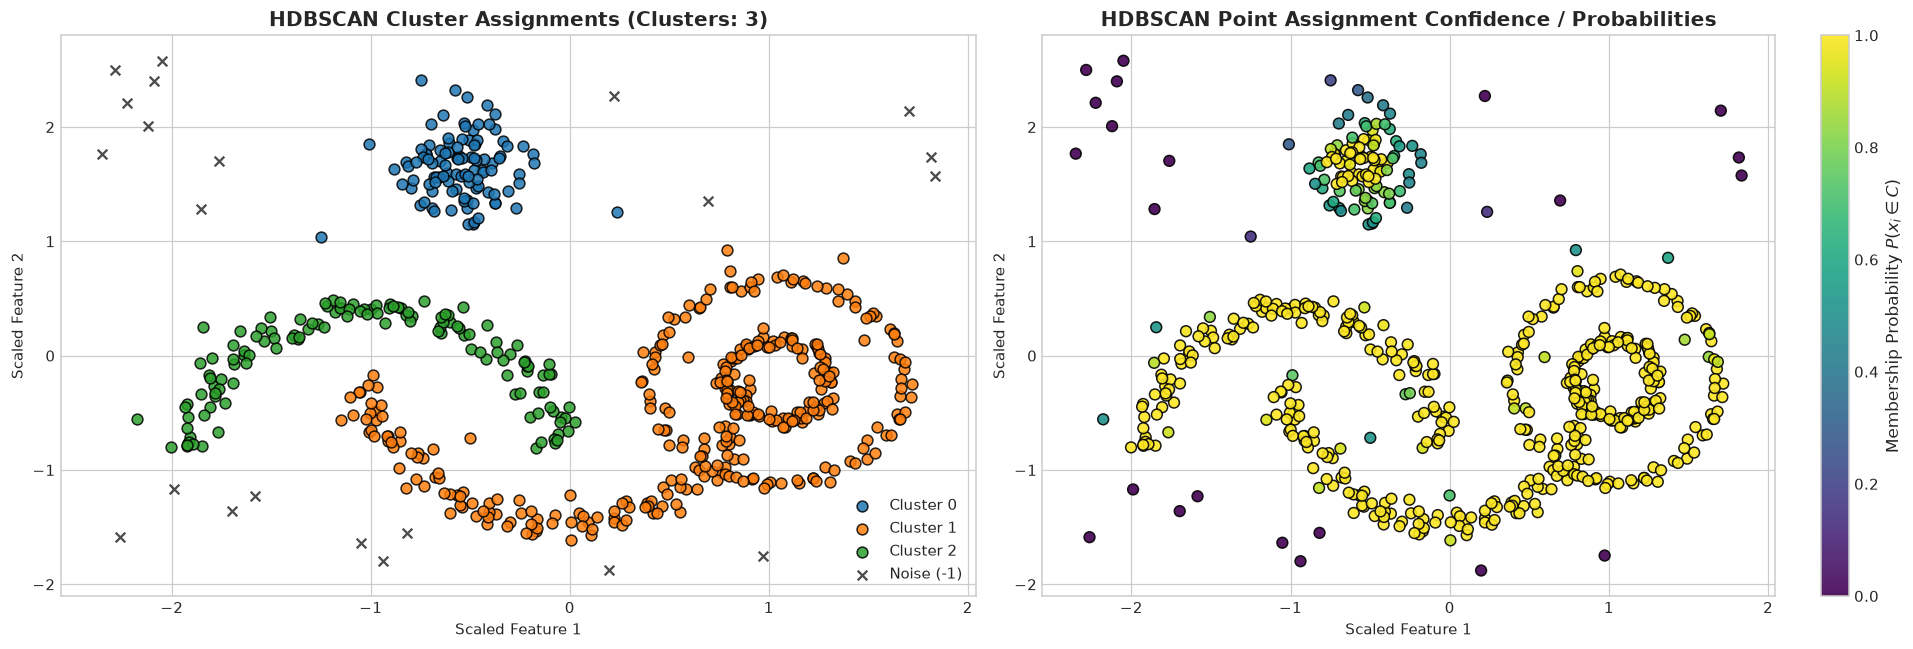

In [8]:
# Visualizing HDBSCAN Clusters and Soft Membership Probabilities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Hard Cluster Assignments
palette = sns.color_palette("tab10", n_clusters_hdb)
for cluster_id in range(n_clusters_hdb):
    pts = X[hdb_labels == cluster_id]
    ax1.scatter(pts[:, 0], pts[:, 1], color=palette[cluster_id], edgecolors='k', s=50, label=f'Cluster {cluster_id}', alpha=0.85)

noise_pts = X[hdb_labels == -1]
ax1.scatter(noise_pts[:, 0], noise_pts[:, 1], color='black', marker='x', s=40, label='Noise (-1)', alpha=0.7)
ax1.set_title(f"HDBSCAN Cluster Assignments (Clusters: {n_clusters_hdb})", fontsize=13, fontweight='bold')
ax1.set_xlabel("Scaled Feature 1")
ax1.set_ylabel("Scaled Feature 2")
ax1.legend()

# Plot 2: Cluster Membership Probabilities
sc = ax2.scatter(X[:, 0], X[:, 1], c=hdb.probabilities_, cmap='viridis', edgecolors='k', s=50, alpha=0.9)
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("Membership Probability $P(x_i \in C)$", fontsize=11)
ax2.set_title("HDBSCAN Point Assignment Confidence / Probabilities", fontsize=13, fontweight='bold')
ax2.set_xlabel("Scaled Feature 1")
ax2.set_ylabel("Scaled Feature 2")

plt.tight_layout()
plt.show()


## 5. Comparative Evaluation: K-Means vs DBSCAN vs HDBSCAN
Let's synthesize our empirical findings across all three algorithms:
- **Adjusted Rand Index (ARI)** measures ground-truth alignment (adjusted for chance, max 1.0).
- **Noise Detection** capability.
- **Silhouette Score** evaluated strictly on clustered non-noise points.


In [9]:
# Compute metrics on clustered (non-noise) samples
def eval_density_algo(name, labels):
    mask = (labels != -1)
    sil = silhouette_score(X[mask], labels[mask]) if len(set(labels[mask])) > 1 else np.nan
    ari = adjusted_rand_score(y_true, labels)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (np.sum(labels == -1) / len(labels)) * 100
    return {
        "Algorithm": name,
        "Clusters Found": n_cl,
        "Noise Points (%)": f"{noise_pct:.1f}%",
        "ARI vs Ground Truth": ari,
        "Silhouette (Non-Noise)": sil
    }

comparison_table = pd.DataFrame([
    eval_density_algo("K-Means", km_labels),
    eval_density_algo("DBSCAN", db_labels),
    eval_density_algo("HDBSCAN", hdb_labels)
]).set_index("Algorithm")

display(comparison_table.style.highlight_max(subset=['ARI vs Ground Truth', 'Silhouette (Non-Noise)'], color='lightgreen'))


,Clusters Found,Noise Points (%),ARI vs Ground Truth,Silhouette (Non-Noise)
Algorithm,,,,
K-Means,5,0.0%,0.442594,0.448428
DBSCAN,3,4.7%,0.463683,0.434245
HDBSCAN,3,3.7%,0.457798,0.433431


## 6. Summary & Algorithmic Takeaways
1. **DBSCAN** excels at extracting arbitrary non-linear shapes and separating anomalies, provided the density throughout the clusters is relatively uniform.
2. **HDBSCAN** eliminates the fragile tuning of a global $\epsilon$ parameter and naturally handles multi-density clusters while producing calibrated cluster membership probabilities.
3. **K-Means** is computationally fast but fundamentally inappropriate for complex topological structures, non-spherical clusters, or noisy datasets.
